# **Training a New Model on the Pre-Trained Model**

Training the model on **CIFAR - 10** Dataset
<br>
Contains 10 labls:
1. Airplane
2. Automobile
3. Bird
4. Cat
5. Deer
6. Dog
7. Frog
8. Horse
9. Ship
10. Truck

In [21]:
import keras
import numpy as np
from keras import layers, Sequential
import keras_hub

### Importing Dataset from Keras Directly

In [22]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

In [23]:
preprocessor = keras_hub.models.ImageClassifierPreprocessor.from_preset(
    "resnet_vd_50_ssld_v2_imagenet"
)

base_model = keras_hub.models.Backbone.from_preset("resnet_vd_50_ssld_v2_imagenet")
base_model.trainable = False

In [24]:
print(f"NUMBER OF IMAGES IN TRAINING DATA : {len(x_train)}")
print(f"NUMBER OF IMAGES IN TEST DATA : {len(x_test)}")

NUMBER OF IMAGES IN TRAINING DATA : 50000
NUMBER OF IMAGES IN TEST DATA : 10000


### Importing Pre-Trained Model

In [25]:
import matplotlib.pyplot as plt

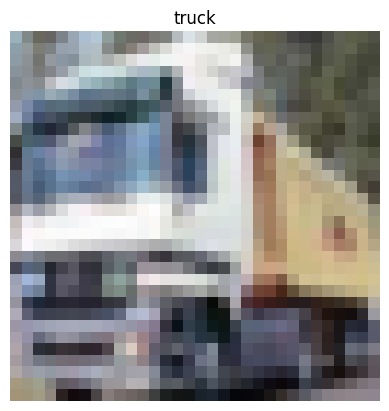

In [26]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]
index = 1
label_index = y_train[index][0]
class_name = class_names[label_index]
plt.imshow(x_train[index])
plt.title(class_name)
plt.axis("off")
plt.show()

In [27]:
model = keras.Sequential([
    preprocessor,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(10, activation="softmax")
])

In [28]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [29]:
model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=5,
    batch_size=64
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 175s 214ms/step - accuracy: 0.9163 - loss: 0.2707 - val_accuracy: 0.9308 - val_loss: 0.2087
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 160s 204ms/step - accuracy: 0.9359 - loss: 0.1907 - val_accuracy: 0.9349 - val_loss: 0.1969
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 161s 206ms/step - accuracy: 0.9416 - loss: 0.1737 - val_accuracy: 0.9367 - val_loss: 0.1936
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 161s 206ms/step - accuracy: 0.9449 - loss: 0.1628 - val_accuracy: 0.9365 - val_loss: 0.1961
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 161s 206ms/step - accuracy: 0.9482 - loss: 0.1548 - val_accuracy: 0.9344 - val_loss: 0.1936


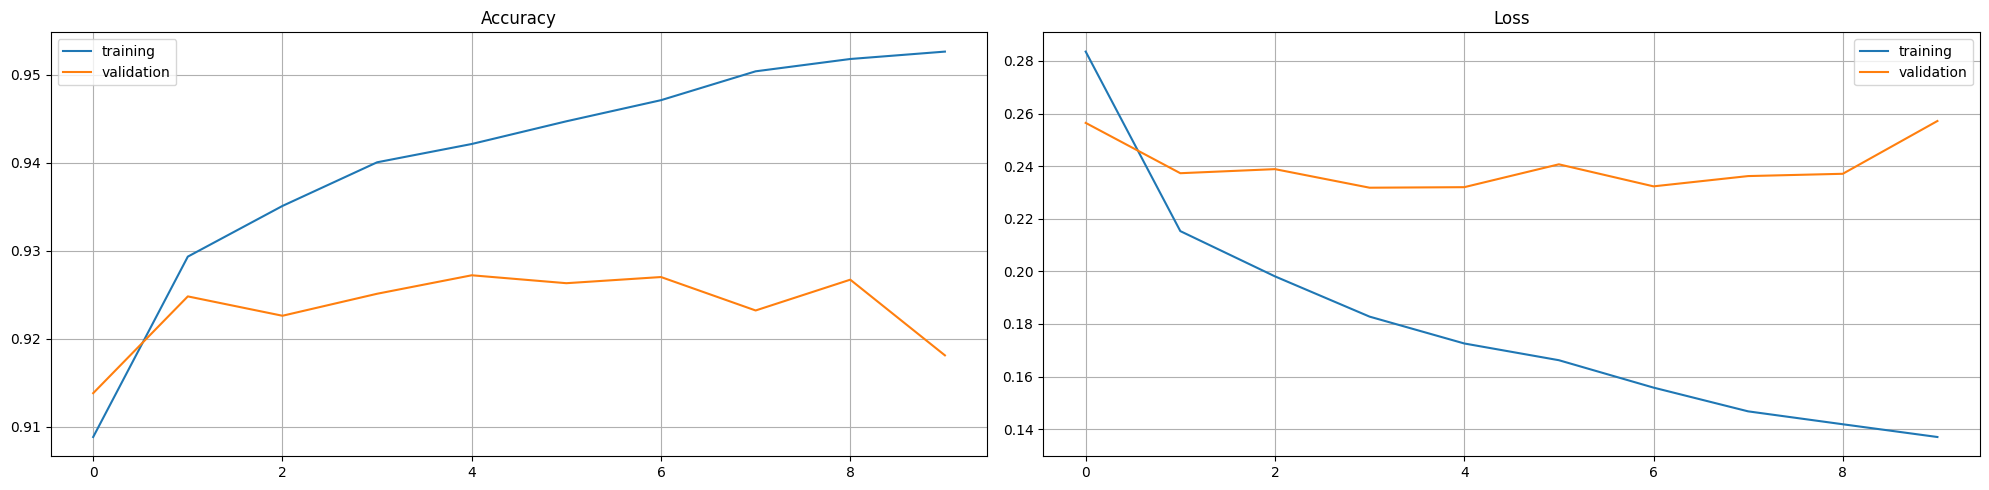

In [31]:
plt.figure(figsize=(20,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='training')
plt.plot(history.history['val_accuracy'], label='validation')
plt.title('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='training')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Loss')
plt.legend()

plt.grid()
plt.tight_layout()
plt.show()

In [43]:
# since we are not using optuna we have to find the best accuracy like this


val_accs = history.history["val_accuracy"]
best_epoch = int(np.argmax(val_accs))

print(f"Best Epoch: {best_epoch + 1}")
print(f"Best Validation Accuracy: {val_accs[best_epoch]:.4f}")
print(f"Best Validation Loss: {history.history['val_loss'][best_epoch]:.4f}")

Best Epoch: 5
Best Validation Accuracy: 0.9272
Best Validation Loss: 0.2320


In [44]:
predictions = model.predict(x_test)

prediction_classes = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 86ms/step


In [50]:
prediction_classes

array([3, 8, 8, ..., 5, 0, 7], shape=(10000,))

In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, prediction_classes, target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.92      0.95      0.93      1000
  automobile       0.96      0.97      0.96      1000
        bird       0.97      0.90      0.93      1000
         cat       0.90      0.85      0.88      1000
        deer       0.94      0.93      0.93      1000
         dog       0.87      0.94      0.90      1000
        frog       0.92      0.97      0.94      1000
       horse       0.97      0.95      0.96      1000
        ship       0.96      0.95      0.95      1000
       truck       0.97      0.93      0.95      1000

    accuracy                           0.93     10000
   macro avg       0.94      0.93      0.93     10000
weighted avg       0.94      0.93      0.93     10000



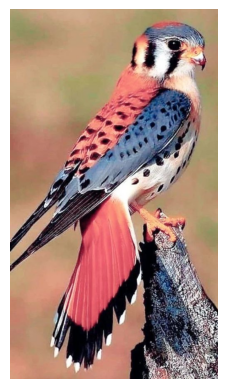

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Predicted Class: bird


In [53]:
image_url = "http://imgs.search.brave.com/WvmxTsvH5ksMpcgrZC8TJTZM5lFnWdG8PEUcKBIBdEE/rs:fit:500:0:1:0/g:ce/aHR0cHM6Ly9pLnBp/bmltZy5jb20vb3Jp/Z2luYWxzLzA2Lzgx/LzliLzA2ODE5YjBk/ZWY1ZDdlZDRhOWJk/Mzg2OWZmOTk3MGVj/LmpwZw"
image_path = keras.utils.get_file(origin=image_url)
img = keras.utils.load_img(image_path)
plt.imshow(img)
plt.axis("off")
plt.show()

img_array = keras.utils.img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)

predictions = model.predict(img_batch)
predicted_class_index = np.argmax(predictions[0])
predicted_class_name = class_names[predicted_class_index]

print(f"Predicted Class: {predicted_class_name}")